In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np
import albumentations as A
import cv2
import torch.nn as nn
import torch
import copy
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="PIL.Image")

In [2]:
print("Текущая директория:", os.getcwd())
os.chdir('/home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/splitted/')
print("Текущая директория:", os.getcwd())

Текущая директория: /home/kalisto/Documents/spbu_dl_2025/homeworks/homework2
Текущая директория: /home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/splitted


(2916, 6)


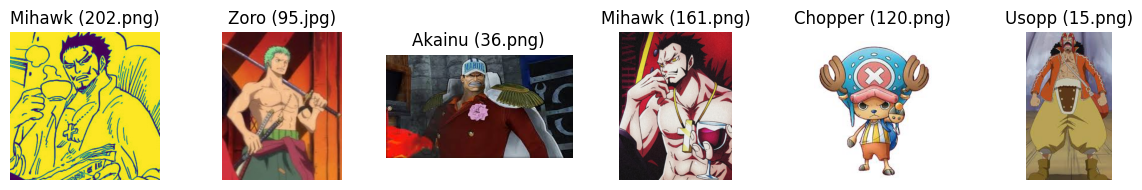

In [3]:

df = pd.read_csv("../train_annotations.csv")
print(df.shape)
show_images = True
if show_images:
    fig, axes = plt.subplots(1, 6, figsize=(12, 2))
    for i, (_, row) in enumerate(df.sample(6).iterrows()):
        img_path_str = row["image_path"].replace("\\", "/")
        img_path = Path(img_path_str)
        img_path = img_path.as_posix()
        if not Path(img_path).is_file():
            img_path = Path(os.getcwd()) / img_path
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{row['class']} ({row['image_name']})")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

In [4]:
# ========== EarlyStopping class ==========
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

class ImageDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.root_dir / row["image_path"].replace("\\", "/")
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = row['label']
        return img, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# ========== Data loading and preprocessing ==========
df = pd.read_csv("../train_annotations.csv")
le = LabelEncoder()
df['label'] = le.fit_transform(df['class'])

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

train_dataset = ImageDataset(
    train_df,
    root_dir='/home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/splitted',
    transform=transform
)
test_dataset = ImageDataset(
    test_df,
    root_dir='/home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/splitted',
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=16, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=16, pin_memory=True)

num_classes = df['label'].nunique()

In [5]:
ORIGINAL_CSV = "../train_annotations.csv"
ORIGINAL_ROOT = "/home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/splitted"
AUG_OUTPUT_DIR = Path("/home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/augmented_train")
AUG_CSV_PATH = "../augmented_train_annotations.csv"
NUM_AUG_PER_IMAGE = 6

AUG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

label_map = {
    "Ace": 0, "Akainu": 1, "Brook": 2, "Chopper": 3, "Crocodile": 4,
    "Franky": 5, "Jinbei": 6, "Kurohige": 7, "Law": 8, "Luffy": 9,
    "Mihawk": 10, "Nami": 11, "Rayleigh": 12, "Robin": 13, "Sanji": 14,
    "Shanks": 15, "Usopp": 16, "Zoro": 17
}

df = pd.read_csv(ORIGINAL_CSV)
df['label'] = df['class'].map(label_map)

inv_label_map = {v: k for k, v in label_map.items()}
class_names = [inv_label_map[i] for i in range(len(inv_label_map))]
train_df, test_df = train_test_split(df, test_size=0.07, stratify=df['label'], random_state=42)

# Аугментации
heavy_aug = A.Compose([
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.1),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.1),
    A.GaussNoise(p=0.2),
    A.ImageCompression(quality_range=(50, 95), p=0.7),
    A.Rotate(limit=5, border_mode=cv2.BORDER_CONSTANT, p=0.3),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale={"x": (0.9, 1.1), "y": (0.9, 1.1)},
        rotate=(-5, 5),
        p=0.3
    ),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
])

augmented_records = []

for idx, row in train_df.iterrows():
    img_path = Path(ORIGINAL_ROOT) / row["image_path"].replace("\\", "/")
    if not img_path.exists():
        continue
    try:
        img_pil = Image.open(img_path).convert("RGB")
        img_np = np.array(img_pil)
    except:
        continue

    orig_name = f"orig_{idx}_{img_path.name}"
    orig_save_path = AUG_OUTPUT_DIR / orig_name
    img_pil.save(orig_save_path)
    augmented_records.append({"image_path": f"augmented_train/{orig_name}", "class": row["class"].replace("\\", "/")})

    for i in range(NUM_AUG_PER_IMAGE):
        try:
            aug_img_np = heavy_aug(image=img_np)["image"]
            aug_img_pil = Image.fromarray(aug_img_np)
            aug_name = f"aug_{idx}_{i}_{img_path.name}"
            aug_save_path = AUG_OUTPUT_DIR / aug_name
            aug_img_pil.save(aug_save_path)
            augmented_records.append({"image_path": f"augmented_train/{aug_name}", "class": row["class"].replace("\\", "/")})
        except:
            continue

aug_df = pd.DataFrame(augmented_records)
aug_df.to_csv(AUG_CSV_PATH, index=False)

In [7]:
train_df, test_df = train_test_split(df, test_size=0.01, stratify=df['label'], random_state=42)


In [ ]:
le_aug = LabelEncoder()
le_aug.fit(class_names)
aug_df['label'] = le_aug.transform(aug_df['class'])

train_dataset = ImageDataset(aug_df, '/home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025', transform)
test_dataset = ImageDataset(test_df, ORIGINAL_ROOT, transform)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=16, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=16, pin_memory=True)

num_classes = len(class_names)

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

early_stopper = EarlyStopping(patience=5, min_delta=1e-5)


In [ ]:
train_losses = []
val_losses = []
accuracies = []

for epoch in range(100):
    model.train()
    train_loss = 0.0
    num_batches = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        num_batches += 1

    avg_train_loss = train_loss / num_batches
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1}, Train loss: {avg_train_loss:.6f}")

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    num_val_batches = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            num_val_batches += 1

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / num_val_batches
    accuracy = correct / total

    val_losses.append(avg_val_loss)
    accuracies.append(accuracy)

    print(f"Validation loss: {avg_val_loss:.6f}, Test accuracy: {accuracy:.4f}")

    if early_stopper.step(avg_val_loss, model):
        print("Early stopping triggered!")
        model.load_state_dict(early_stopper.best_state)
        break

print("Training finished.")

Epoch 1, Train loss: 2.851181
Validation loss: 2.445102, Test accuracy: 0.2333
Epoch 2, Train loss: 2.284926
Validation loss: 1.903438, Test accuracy: 0.6333
Epoch 3, Train loss: 1.825206
Validation loss: 1.493124, Test accuracy: 0.7000
Epoch 4, Train loss: 1.474772
Validation loss: 1.224483, Test accuracy: 0.7333
Epoch 5, Train loss: 1.230101
Validation loss: 1.022843, Test accuracy: 0.8333
Epoch 6, Train loss: 1.028016
Validation loss: 0.886390, Test accuracy: 0.8333
Epoch 7, Train loss: 0.872673
Validation loss: 0.776749, Test accuracy: 0.8333
Epoch 8, Train loss: 0.748350
Validation loss: 0.689969, Test accuracy: 0.8667
Epoch 9, Train loss: 0.641057
Validation loss: 0.629389, Test accuracy: 0.8667
Epoch 10, Train loss: 0.562376
Validation loss: 0.578720, Test accuracy: 0.9000
Epoch 11, Train loss: 0.487919
Validation loss: 0.543125, Test accuracy: 0.9000
Epoch 12, Train loss: 0.421836
Validation loss: 0.514185, Test accuracy: 0.9333
Epoch 13, Train loss: 0.367946
Validation loss: 0

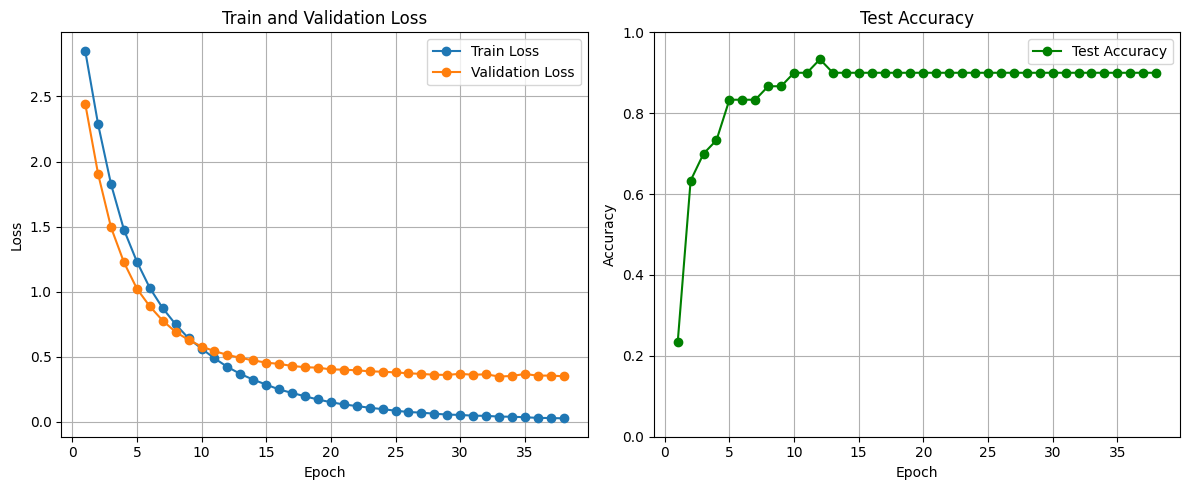

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.title('Train and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, accuracies, label='Test Accuracy', color='green', marker='o')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## resnet50
### 1 try
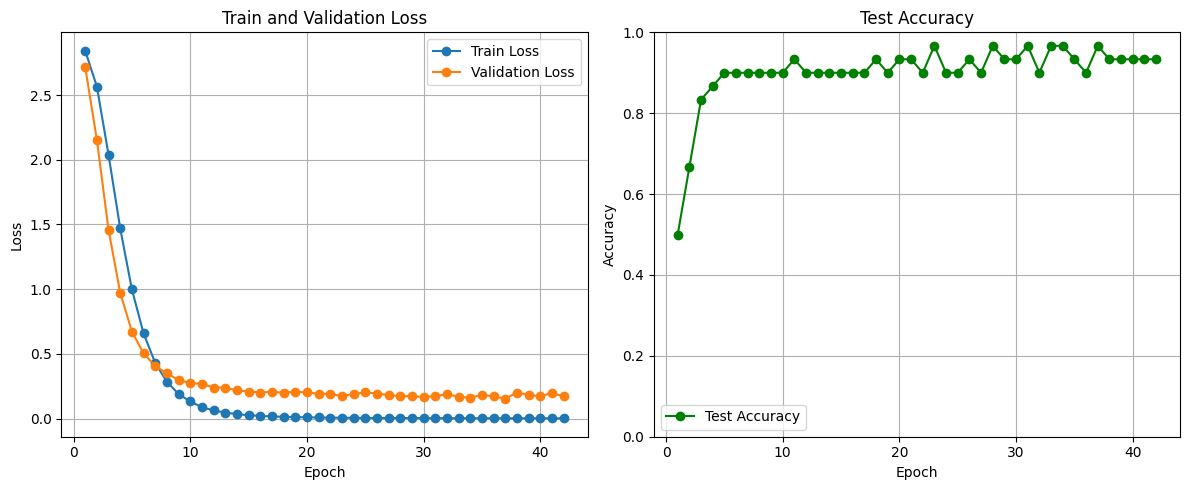
### 2 try
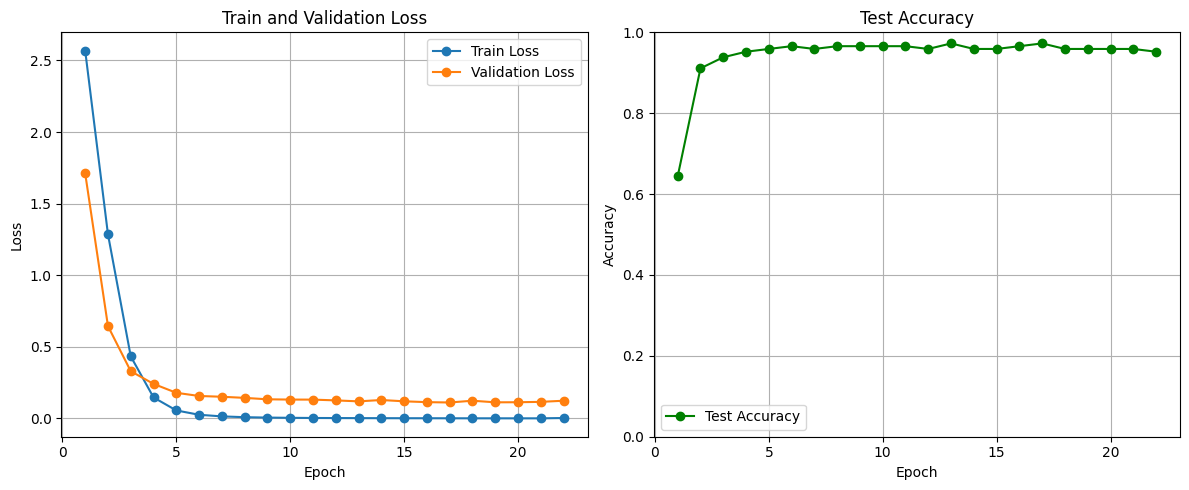
## resnet18
### 3 try
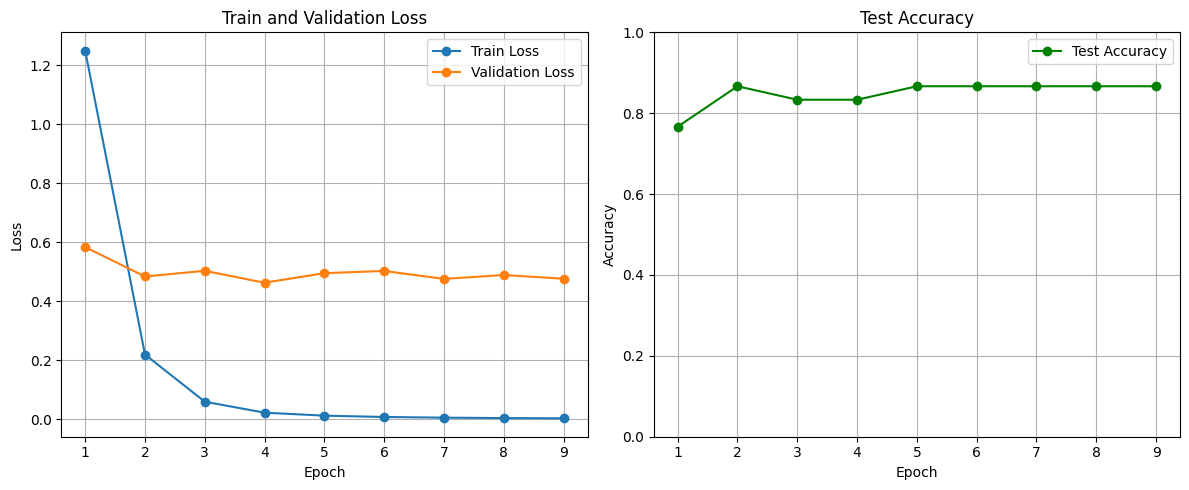
### 4 try
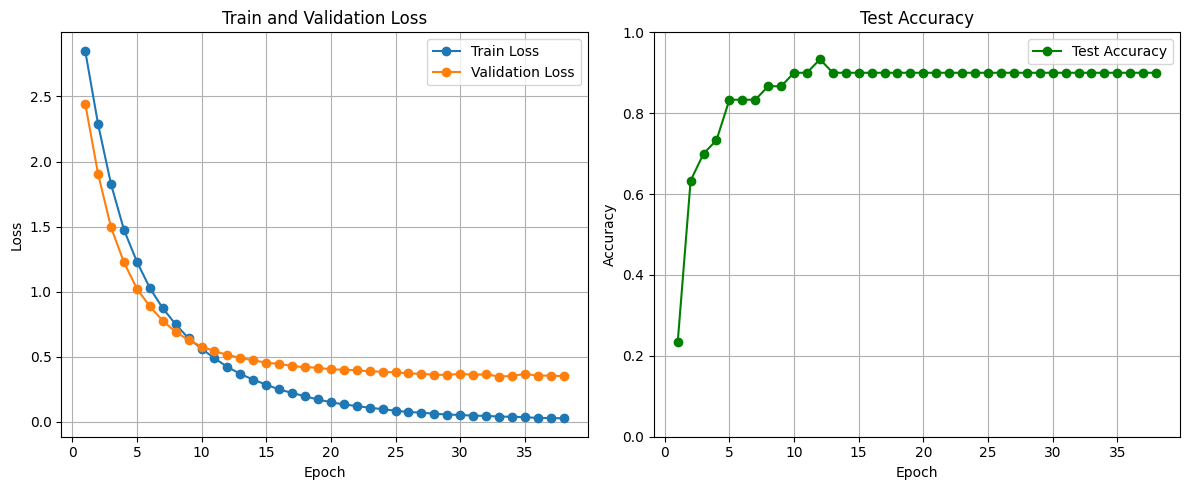

In [27]:
torch.save(model.state_dict(), "model_weights_resnet18_augmented.pth")

In [ ]:
IMAGE_DIR = "/home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/splitted/test"  # Adjust if images are elsewhere
CSV_PATH = "/home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/submission.csv"
MODEL_PATH = "model_weights_resnet50_augmented.pth"
OUTPUT_CSV = "/home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/submission_predictions.csv"

label_map = {
    0: "Ace", 1: "Akainu", 2: "Brook", 3: "Chopper", 4: "Crocodile",
    5: "Franky", 6: "Jinbei", 7: "Kurohige", 8: "Law", 9: "Luffy",
    10: "Mihawk", 11: "Nami", 12: "Rayleigh", 13: "Robin", 14: "Sanji",
    15: "Shanks", 16: "Usopp", 17: "Zoro"
}
class SubmissionDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.iloc[idx]["id"]
        for ext in [".jpg", ".jpeg", ".png"]:
            img_path = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(img_path):
                image = Image.open(img_path).convert("RGB")
                if self.transform:
                    image = self.transform(image)
                return img_id, image
        raise FileNotFoundError(f"Image {img_id} not found in {self.img_dir} (tried .jpg, .jpeg, .png)")

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

dataset = SubmissionDataset(CSV_PATH, IMAGE_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=4)

results = []

with torch.no_grad():
    for img_ids, images in dataloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for i in range(len(img_ids)):
            results.append({
                "id": img_ids[i],
                "label": preds[i].item()
            })

df_out = pd.DataFrame(results)
df_out.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df_out)} predictions to {OUTPUT_CSV}")

✅ Saved 849 predictions to /home/kalisto/Documents/spbu_dl_2025/data/one-piece-classification-2025/submission_predictions.csv
